In [17]:
%pip install joblib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Step 1: Import Libraries and Load Data
## First, we set up our environment and load the dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.utils import resample
import tensorflow as tf
from tensorflow import keras # type: ignore
from tensorflow.keras import layers # type: ignore
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import keras_tuner as kt
import joblib
import os
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [3]:
# Load the data
df = pd.read_csv('dataset/respiratory symptoms and treatment.csv')

# Initial inspection
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 18069 entries, 0 to 18068
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Symptoms    17925 non-null  str    
 1   Age         17995 non-null  float64
 2   Sex         17563 non-null  str    
 3   Disease     18069 non-null  str    
 4   Treatment   17317 non-null  str    
 5   Nature      17227 non-null  str    
 6   Unnamed: 6  0 non-null      float64
 7   Unnamed: 7  0 non-null      float64
 8   Unnamed: 8  0 non-null      float64
dtypes: float64(4), str(5)
memory usage: 1.2 MB
None
                     Symptoms  Age     Sex Disease    Treatment Nature  \
0                   coughing   5.0  female  Asthma   Omalizumab   high   
1  tight feeling in the chest  4.0  female  Asthma  Mepolizumab   high   
2                    wheezing  6.0    male  Asthma  Mepolizumab   high   
3         shortness of breath  7.0    male  Asthma  Mepolizumab   high   
4         shortness of breath

In [3]:
df.head()

,Symptoms,Age,Sex,Disease,Treatment,Nature,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,coughing,5.0,female,Asthma,Omalizumab,high,NaN,NaN,NaN
1,tight feeling in the chest,4.0,female,Asthma,Mepolizumab,high,NaN,NaN,NaN
2,wheezing,6.0,male,Asthma,Mepolizumab,high,NaN,NaN,NaN
3,shortness of breath,7.0,male,Asthma,Mepolizumab,high,NaN,NaN,NaN
4,shortness of breath,9.0,male,Asthma,Mepolizumab,high,NaN,NaN,NaN


# Step 2: Data Cleaning
## In this step, we remove redundant columns and fix formatting issues (like extra spaces in text).

In [4]:
df["Disease"].value_counts()

Disease
Pneumonia                                6144
bronchitis                               4925
chronic obstructive pulmonary disease    3888
Chronic Bronchitis                       2016
Asthma                                   1096
Name: count, dtype: int64

In [5]:
# Drop completely empty unnamed columns
df.drop(columns=['Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8','Treatment','Nature'], inplace=True, errors='ignore')

#  Strip whitespace from all string columns (crucial for matching categories)
df['Disease'] = df['Disease'].str.lower().str.strip()
df['Symptoms'] = df['Symptoms'].str.lower().str.strip()

# Keep only required diseases
target_diseases = ['asthma', 'bronchitis', 'pneumonia', 
                   'chronic obstructive pulmonary disease']

df = df[df['Disease'].isin(target_diseases)]

# Rename COPD for simplicity
df['Disease'] = df['Disease'].replace(
    {'chronic obstructive pulmonary disease': 'copd'}
)
# Handle Missing Values
# Impute Age with median (more robust to outliers)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Impute categorical columns with the Mode (most frequent value)
for col in ['Symptoms', 'Sex']:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after cleaning:", df.isnull().sum().sum())
print("After Cleaning:", df.shape)

Missing values after cleaning: 0
After Cleaning: (16053, 4)


In [6]:
len(df['Symptoms'].value_counts())

28

In [7]:
df['Symptoms'].value_counts()

Symptoms
fatigue                            1488
wheezing                           1341
shortness of breath                1236
yellow cough                       1118
chronic cough                       864
cold                                845
low-grade fever                     685
mucus                               672
chest pain                          672
nausea                              672
feeling run-down or tired           624
whistling sound while breathing     538
runny nose                          535
stuffy nose                         489
fever                               461
chest congestion                    440
greenish cough                      336
cough with blood                    336
sweating                            336
shaking                             336
rapid breathing                     336
shallow breathing                   336
low energy                          336
loss of appetite                    336
vomiting                       

In [48]:
df.head()

,Symptoms,Age,Sex,Disease
0,coughing,5.0,female,asthma
1,tight feeling in the chest,4.0,female,asthma
2,wheezing,6.0,male,asthma
3,shortness of breath,7.0,male,asthma
4,shortness of breath,9.0,male,asthma


# Step 3: Exploratory Data Analysis (EDA)
## Visualizing the data helps understand distributions and class imbalances.

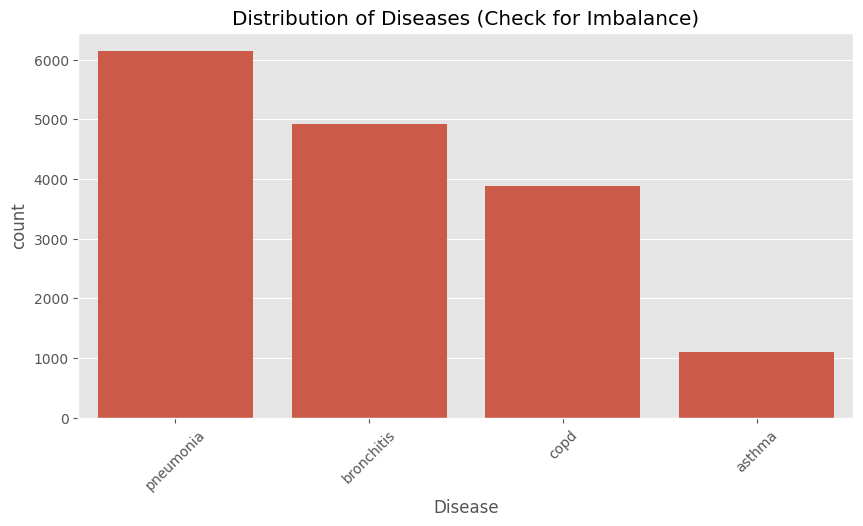

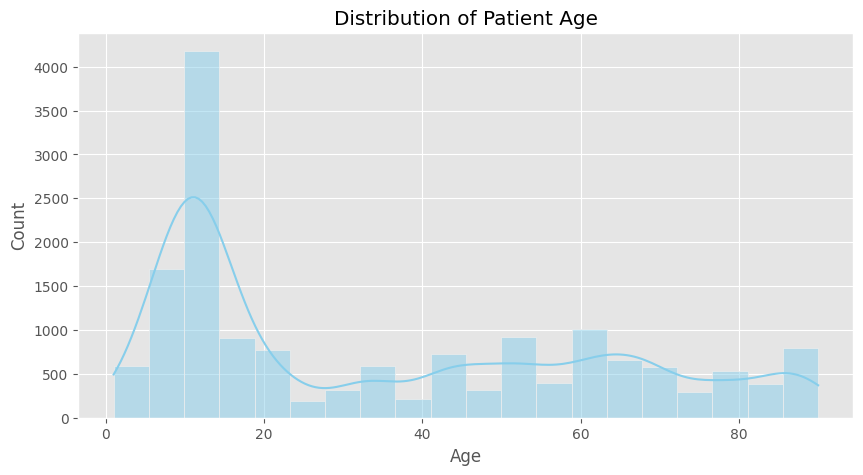

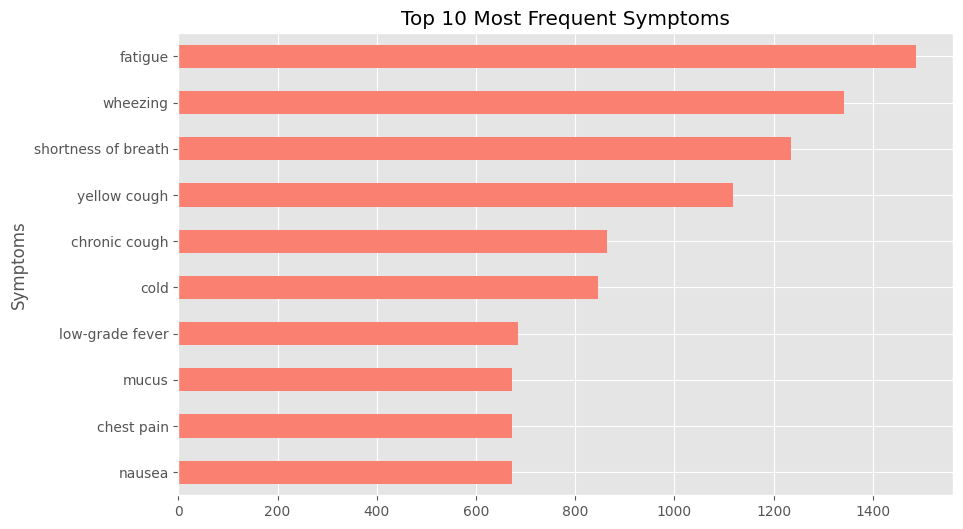

In [8]:
plt.style.use('ggplot')

# 1. Distribution of the Target (Disease)
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Disease', order=df['Disease'].value_counts().index)
plt.title('Distribution of Diseases (Check for Imbalance)')
plt.xticks(rotation=45)
plt.show()

# 2. Age Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue') # type: ignore
plt.title('Distribution of Patient Age')
plt.show()

# 3. Symptoms Analysis
plt.figure(figsize=(10, 6))
df['Symptoms'].value_counts().nlargest(10).plot(kind='barh', color='salmon')
plt.title('Top 10 Most Frequent Symptoms')
plt.gca().invert_yaxis()
plt.show()

# Step 4: Train-Test Split and Handling Imbalance
## Since your data is imbalanced (e.g., Asthma is much less frequent than Pneumonia), we use oversampling on the training set to ensure the model learns all classes equally.


In [9]:
# 1. Split features (X) and target (y)
X = df[['Symptoms', 'Age', 'Sex']]
y = df['Disease']
# Encode target labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# 2. Initial Train-Test Split (80/20)
# We use 'stratify' to keep the original distribution in the test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


array([3, 3, 1, ..., 2, 3, 3], shape=(12842,))


# Step 5: Data Preprocessing (Scaling & Encoding)
## Machine learning models require numerical data. We scale numerical features and encode categorical ones.

In [14]:


# 1. Scale Numerical Features (Age)
# 2. Encode Categorical Features (One-Hot Encoding)
# This converts categories into binary columns (0 and 1)
categorical_features = ['Symptoms', 'Sex']
numeric_features = ['Age']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

# Fit preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)



input_dim = X_train_processed.shape[1]

# ------------------------------
# 6. HANDLE CLASS IMBALANCE
# ------------------------------

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))


In [15]:
input_dim

32

In [13]:
# Save preprocessor
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [24]:
def build_model(hp):
    model = Sequential()

    model.add(Dense(
        units=hp.Int('units1', 64, 256, step=64),
        activation='relu',
        input_dim=input_dim
    ))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(Dropout(hp.Float('dropout1', 0.2, 0.5, step=0.1)))

    model.add(Dense(
        units=hp.Int('units2', 32, 128, step=32),
        activation='relu'
    ))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(Dropout(hp.Float('dropout2', 0.2, 0.5, step=0.1)))

    model.add(Dense(4, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [25]:
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=50,
    factor=3,
    directory='mydir',
    project_name='lung_model'
)


In [26]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

tuner.search(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=50,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)


Trial 90 Complete [00h 00m 42s]
val_accuracy: 0.8890618681907654

Best val_accuracy So Far: 0.8995718359947205
Total elapsed time: 00h 22m 53s


In [29]:
tuner.get_best_hyperparameters()[0].values

{'units1': 128,
 'dropout1': 0.30000000000000004,
 'units2': 96,
 'dropout2': 0.4,
 'learning_rate': 0.001,
 'tuner/epochs': 6,
 'tuner/initial_epoch': 0,
 'tuner/bracket': 2,
 'tuner/round': 0}

In [30]:
best_model = tuner.get_best_models(num_models=1)[0]

c:\Users\zulqa\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\zulqa\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [32]:
history = best_model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_test_processed, y_test),
    epochs=100,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8551 - loss: 0.3458 - val_accuracy: 0.8723 - val_loss: 0.2647
Epoch 2/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8563 - loss: 0.3301 - val_accuracy: 0.8770 - val_loss: 0.2686
Epoch 3/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8526 - loss: 0.3335 - val_accuracy: 0.8655 - val_loss: 0.2641
Epoch 4/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8557 - loss: 0.3219 - val_accuracy: 0.8409 - val_loss: 0.2835
Epoch 5/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8568 - loss: 0.3158 - val_accuracy: 0.8729 - val_loss: 0.2505
Epoch 6/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8598 - loss: 0.3091 - val_accuracy: 0.8704 - val_loss: 0.2555
Epoch 7/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8625 - loss: 0.3081 - val_accuracy: 0.8399 - val_loss: 0.2698
Epoch 8/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8583 - loss: 0.3069 - val_accu

In [33]:

test_loss, test_acc = best_model.evaluate(X_test_processed, y_test)
print("\nFinal Test Accuracy:", test_acc)

y_pred = np.argmax(best_model.predict(X_test_processed), axis=1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9253 - loss: 0.1490

Final Test Accuracy: 0.9252569079399109
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Classification Report:
              precision    recall  f1-score   support

      asthma       0.65      0.96      0.77       219
  bronchitis       0.96      0.97      0.97       985
        copd       0.90      0.87      0.88       778
   pneumonia       0.99      0.92      0.95      1229

    accuracy                           0.93      3211
   macro avg       0.87      0.93      0.89      3211
weighted avg       0.94      0.93      0.93      3211


Confusion Matrix:
[[ 210    4    5    0]
 [  14  956   15    0]
 [  83    8  679    8]
 [  17   28   58 1126]]


Starting Final Training with Best Hyperparameters...
Epoch 1/50
768/768 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1999 - loss: 1.6110 - val_accuracy: 0.2726 - val_loss: 1.6054
Epoch 2/50
768/768 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1978 - loss: 1.6097 - val_accuracy: 0.2153 - val_loss: 1.6073
Epoch 3/50
768/768 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1956 - loss: 1.6101 - val_accuracy: 0.3401 - val_loss: 1.6093
Epoch 4/50
768/768 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1978 - loss: 1.6099 - val_accuracy: 0.2726 - val_loss: 1.6084
Epoch 5/50
768/768 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1992 - loss: 1.6100 - val_accuracy: 0.2726 - val_loss: 1.6086
Epoch 6/50
768/768 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1958 - loss: 1.6098 - val_accuracy: 0.2726 - val_loss: 1.6081
Epoch 7/50
768/768 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1981 - loss: 1.6099 - val_accuracy: 0.2726 - val_loss: 1.6060
Epoch 8/50
768/768 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

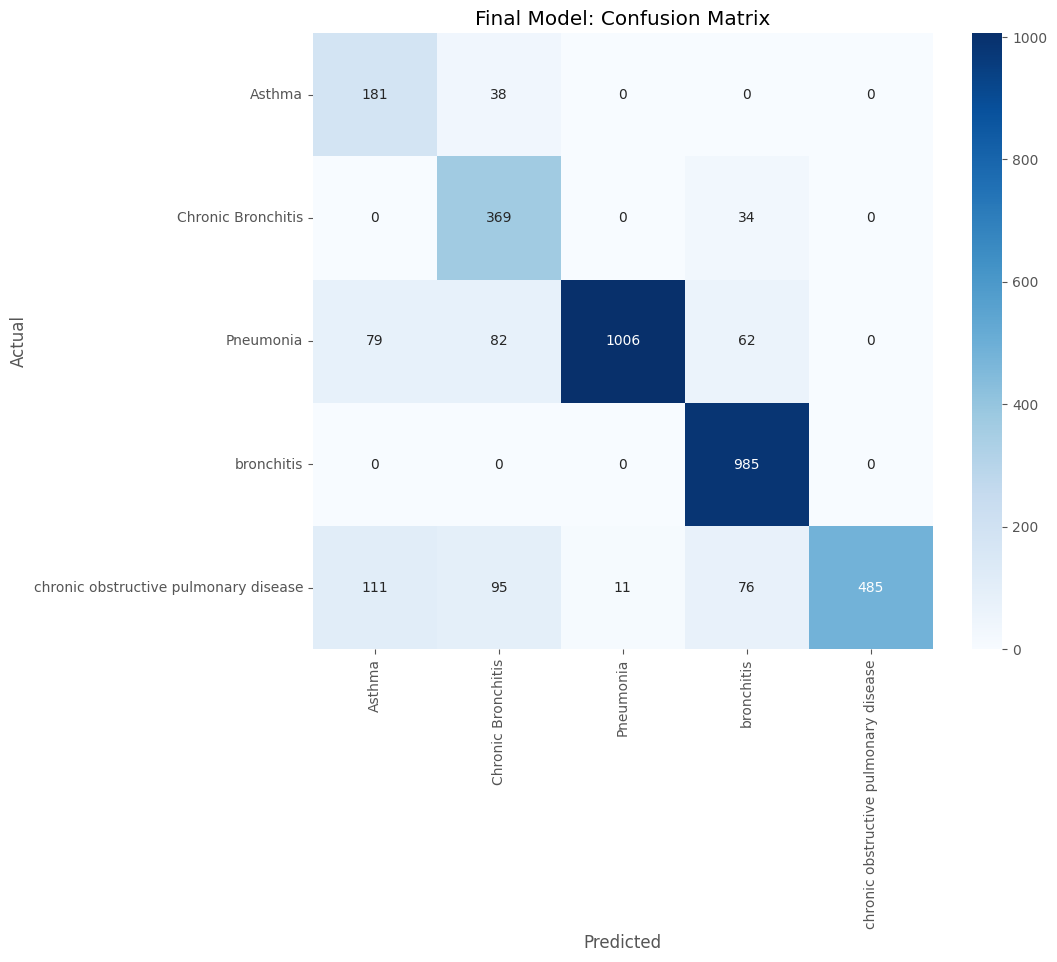

Production model saved as 'respiratory_disease_model.keras'


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input

# 1. Get the best hyperparameters from the tuner
# Changed 'num_models' to 'num_trials' to fix the TypeError
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# 2. Build the model using the best parameters
def build_final_model(hp):
    model = Sequential()
    
    # Use Input layer to avoid the UserWarning
    model.add(Input(shape=(X_train_resampled.shape[1],)))
    
    # Dynamically build layers based on the best hyperparams found
    num_layers = hp.get('num_layers')
    for i in range(num_layers):
        model.add(Dense(
            units=hp.get(f'units{i}'),
            activation=hp.get(f'activation{i}')
        ))
        # Use a default if the dropout key for a specific layer index wasn't created
        dropout_rate = hp.get(f'Dropout{i}') if hp.values.get(f'Dropout{i}') is not None else 0.2
        model.add(Dropout(dropout_rate))
    
    # Output layer for 5 classes
    model.add(Dense(5, activation='softmax'))
    
    model.compile(
        optimizer=hp.get('optimizer'),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Create the final model instance
final_model = build_final_model(best_hps)

# 3. Train the model
print("Starting Final Training with Best Hyperparameters...")
history = final_model.fit(
    X_train_resampled, 
    y_train_resampled, 
    epochs=50, 
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# 4. Evaluation
y_pred_probs = final_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 5. Classification Report
# Ensure 'le' (LabelEncoder) is defined from your previous steps
print("\n--- Final Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 6. Confusion Matrix Plot
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Model: Confusion Matrix')
plt.show()

# 7. Save for production
final_model.save('respiratory_disease_model.keras')
print("Production model saved as 'respiratory_disease_model.keras'")